# Diabetes Prediction — Data Science Project

## Introduction

Diabetes is one of the most common chronic diseases in the world, affecting millions of people globally.
In this project, we are building a **Machine Learning model** that can predict whether a person
has diabetes or not, based on their **medical and demographic information**.

### Dataset Overview
The dataset contains **100,000 patient records** with the following features:

- **gender** — Male / Female / Other
- **age** — Age of the patient
- **hypertension** — Whether the patient has hypertension (0 = No, 1 = Yes)
- **heart_disease** — Whether the patient has heart disease (0 = No, 1 = Yes)
- **smoking_history** — Smoking habits of the patient
- **bmi** — Body Mass Index
- **HbA1c_level** — Average blood sugar level over the past 3 months
- **blood_glucose_level** — Current blood glucose level
- **diabetes** — Target column (0 = No Diabetes, 1 = Has Diabetes)

### Project Workflow
1. Import Libraries and Load Data
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building
5. Model Evaluation

In [3]:
# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/sample_data/diabetes_prediction_dataset.csv')
# First look at the data
print(" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print(" First 5 rows:")
df.head()

 Dataset loaded successfully!
 Shape: 100000 rows × 9 columns

 First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Step 2: Exploratory Data Analysis (EDA)

Before building any model, we need to **understand our data deeply**.
EDA helps us answer key questions like:

- Are there any **missing values**?
- What do the **data types** look like?
- How is the **target variable (diabetes)** distributed — is the data balanced or imbalanced?
- What are the **basic statistics** (mean, min, max) of each column?

This step ensures we know exactly what we are working with before touching the data.

In [4]:
# Basic info about the dataset
print("Column Names and Data Types:")
print(df.dtypes)
print()

# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())
print()

# Basic statistics
print("Basic Statistical Summary:")
df.describe()

Column Names and Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Missing Values in Each Column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Basic Statistical Summary:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Step 3: Data Visualization

Now that we understand the basic structure of our data, we will **visualize** it.
Graphs help us see patterns that numbers alone cannot show us clearly.

We will plot the following:

- **Target variable distribution** — How many patients have diabetes vs do not have diabetes
- **Age distribution** — What is the age spread of our patients
- **BMI distribution** — How BMI is spread across the dataset
- **HbA1c and Blood Glucose levels** — These are the most critical medical indicators for diabetes
- **Correlation heatmap** — Which features are most related to each other

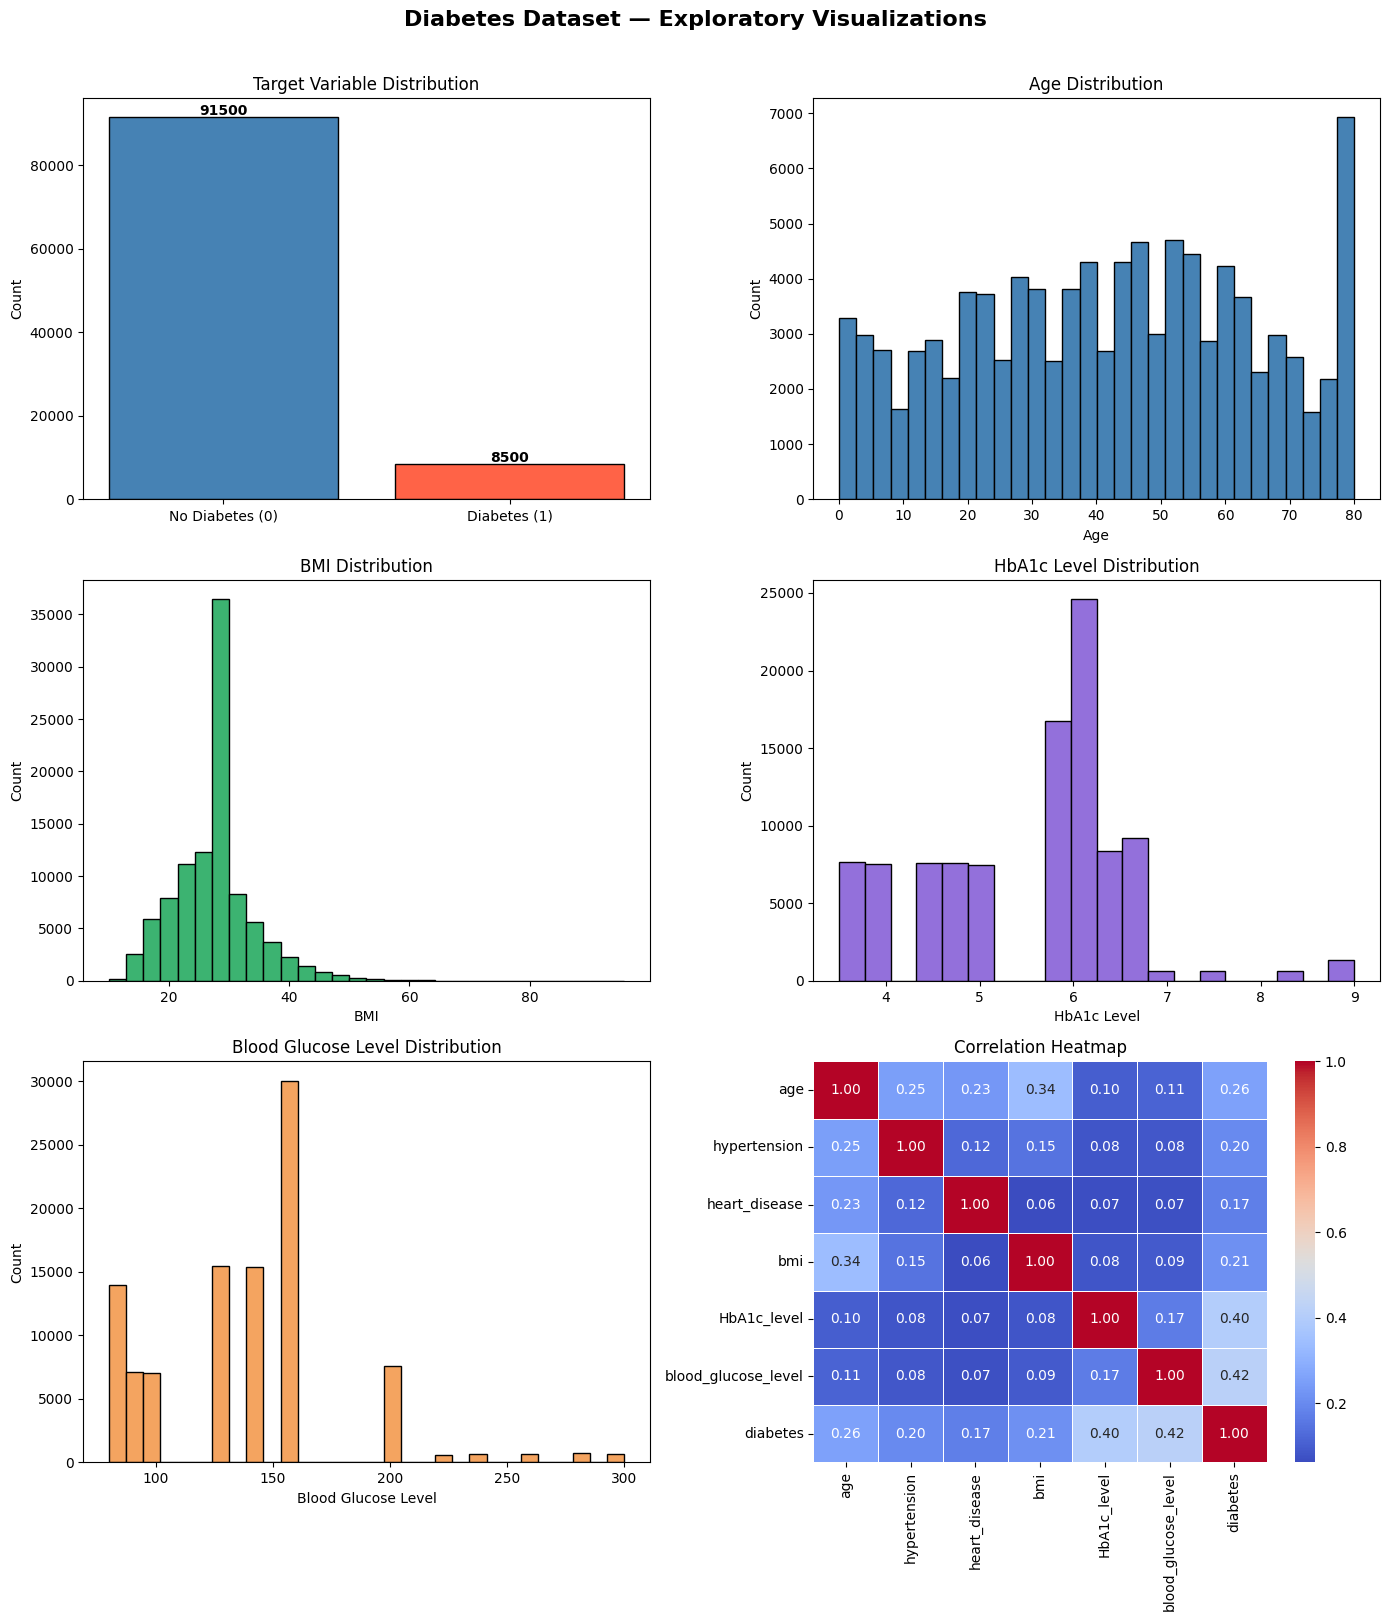

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Diabetes Dataset — Exploratory Visualizations', fontsize=16, fontweight='bold', y=1.01)

# 1. Target variable distribution
axes[0, 0].bar(['No Diabetes (0)', 'Diabetes (1)'],
               df['diabetes'].value_counts().values,
               color=['steelblue', 'tomato'], edgecolor='black')
axes[0, 0].set_title('Target Variable Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(df['diabetes'].value_counts().values):
    axes[0, 0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# 2. Age distribution
axes[0, 1].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')

# 3. BMI distribution
axes[1, 0].hist(df['bmi'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('BMI Distribution')
axes[1, 0].set_xlabel('BMI')
axes[1, 0].set_ylabel('Count')

# 4. HbA1c Level distribution
axes[1, 1].hist(df['HbA1c_level'], bins=20, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('HbA1c Level Distribution')
axes[1, 1].set_xlabel('HbA1c Level')
axes[1, 1].set_ylabel('Count')

# 5. Blood Glucose Level distribution
axes[2, 0].hist(df['blood_glucose_level'], bins=30, color='sandybrown', edgecolor='black')
axes[2, 0].set_title('Blood Glucose Level Distribution')
axes[2, 0].set_xlabel('Blood Glucose Level')
axes[2, 0].set_ylabel('Count')

# 6. Correlation heatmap
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2, 1], linewidths=0.5)
axes[2, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

Raw data is never ready for a machine learning model directly. We need to **clean and prepare** it first.

In this step we will:

- **Encode categorical columns** — Machine learning models only understand numbers, so we convert
  text columns like `gender` and `smoking_history` into numeric form using Label Encoding
- **Check class imbalance** — Our target column `diabetes` has far more 0s than 1s (about 91% vs 9%).
  This means if we train a model as-is, it will be biased towards predicting No Diabetes always.
  We fix this using **SMOTE** (Synthetic Minority Oversampling Technique) which creates synthetic
  samples of the minority class to balance the dataset
- **Split the data** — We divide data into **training set (80%)** and **testing set (20%)**
- **Standardize features** — We scale all numeric columns to the same range using **StandardScaler**
  so that no single feature dominates the model due to its large numeric range

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# -----------------------------------------------
# Step 1: Encode categorical columns
# -----------------------------------------------
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])

print("Categorical columns encoded successfully.")
print(df[['gender', 'smoking_history']].value_counts().head(8))

# -----------------------------------------------
# Step 2: Check class imbalance
# -----------------------------------------------
print("\nClass distribution before SMOTE:")
print(df['diabetes'].value_counts())
print(f"Imbalance ratio: {round(df['diabetes'].value_counts()[0] / df['diabetes'].value_counts()[1], 2)}:1")

# -----------------------------------------------
# Step 3: Define features and target
# -----------------------------------------------
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# -----------------------------------------------
# Step 4: Apply SMOTE to balance classes
# -----------------------------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# -----------------------------------------------
# Step 5: Train-Test Split
# -----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")

# -----------------------------------------------
# Step 6: Standardize features
# -----------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeatures standardized successfully.")

Categorical columns encoded successfully.
gender  smoking_history
0       4                  22869
        0                  19700
1       0                  16110
        4                  12223
0       1                   5058
        3                   4774
1       3                   4578
        1                   4228
Name: count, dtype: int64

Class distribution before SMOTE:
diabetes
0    91500
1     8500
Name: count, dtype: int64
Imbalance ratio: 10.76:1

Class distribution after SMOTE:
diabetes
0    91500
1    91500
Name: count, dtype: int64

Training set size: 146400 rows
Testing set size:  36600 rows

Features standardized successfully.


## Step 5: Model Building

Now that our data is clean, balanced, and scaled — we are ready to **train machine learning models**.

We will train **three different models** and compare them:

- **Logistic Regression** — A simple, interpretable baseline model. It finds a linear boundary
  between diabetic and non-diabetic patients
- **Random Forest** — An ensemble of many decision trees. It is more powerful and handles
  non-linear relationships well
- **XGBoost** — A gradient boosting algorithm that is widely used in competitions and real-world
  projects. It builds trees sequentially, each one correcting the errors of the previous one

Training multiple models and comparing them is standard practice in data science —
we never just rely on one model.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)


# Define all three models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}


# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc      = accuracy_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': round(acc, 4), 'ROC-AUC': round(roc_auc, 4)}

    print(f"\n--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
    print("-" * 60)


# Summary comparison table

print("\nModel Comparison Summary:")
print(pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False))

Training Logistic Regression...

--- Logistic Regression ---
Accuracy : 0.8854
ROC-AUC  : 0.9624
Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.89      0.88      0.89     18293
    Diabetes       0.88      0.89      0.89     18307

    accuracy                           0.89     36600
   macro avg       0.89      0.89      0.89     36600
weighted avg       0.89      0.89      0.89     36600

------------------------------------------------------------
Training Random Forest...

--- Random Forest ---
Accuracy : 0.9752
ROC-AUC  : 0.9972
Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.97      0.98      0.98     18293
    Diabetes       0.98      0.97      0.98     18307

    accuracy                           0.98     36600
   macro avg       0.98      0.98      0.98     36600
weighted avg       0.98      0.98      0.98     36600

---------------------------------------------------------

## Step 6: Model Evaluation — Visualization

Numbers alone do not tell the full story. We now **visualize the performance** of all three models
to better understand where each model succeeds and where it struggles.

We will plot:

- **Confusion Matrix** for each model — shows exactly how many predictions were correct,
  and what type of errors the model made (false positives vs false negatives)
- **ROC Curve** for all three models together — shows the trade-off between true positive rate
  and false positive rate. The closer the curve is to the top-left corner, the better the model

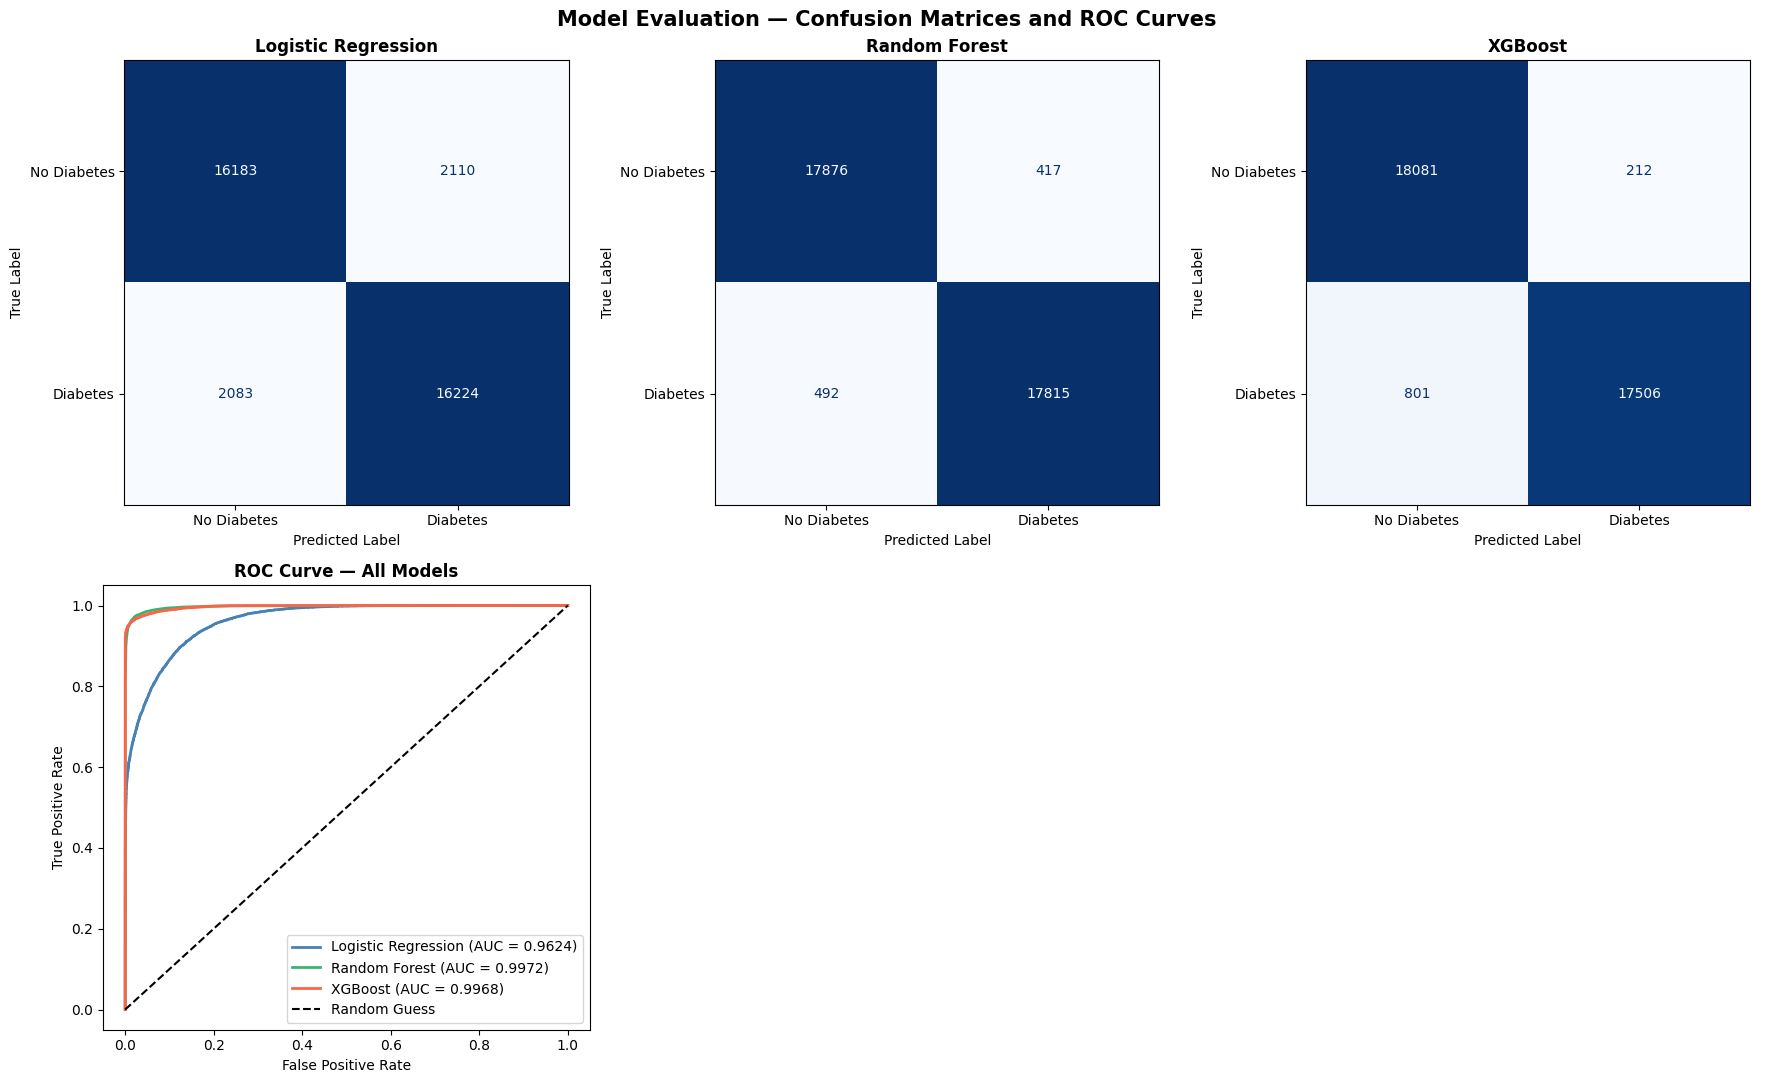

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation — Confusion Matrices and ROC Curves',
             fontsize=15, fontweight='bold')

model_names  = list(models.keys())
colors       = ['steelblue', 'mediumseagreen', 'tomato']

# -----------------------------------------------
# Row 1: Confusion Matrices
# -----------------------------------------------
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=axes[0, i], colorbar=False, cmap='Blues')
    axes[0, i].set_title(f'{name}', fontweight='bold')
    axes[0, i].set_xlabel('Predicted Label')
    axes[0, i].set_ylabel('True Label')

# -----------------------------------------------
# Row 2: ROC Curves (all 3 on one plot, rest hidden)
# -----------------------------------------------
for i, (name, model) in enumerate(models.items()):
    y_prob          = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _     = roc_curve(y_test, y_prob)
    auc             = roc_auc_score(y_test, y_prob)
    axes[1, 0].plot(fpr, tpr, color=colors[i], lw=2,
                    label=f'{name} (AUC = {auc:.4f})')

axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')
axes[1, 0].set_title('ROC Curve — All Models', fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')

# Hide unused subplots
axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Step 7: Feature Importance

Now that we have our best model — **Random Forest** — we want to understand **why** it makes
the predictions it does.

Feature importance tells us **which input variables had the most influence** on predicting diabetes.
This is extremely valuable because:

- It gives us **medical insight** — which factors actually matter for diabetes prediction
- It helps us understand if the model is making **logical, real-world sense**
- In real projects, it can help doctors **focus on the most critical indicators** for a patient

We expect **HbA1c level** and **Blood Glucose Level** to be the top features,
since we already saw this in our correlation heatmap.

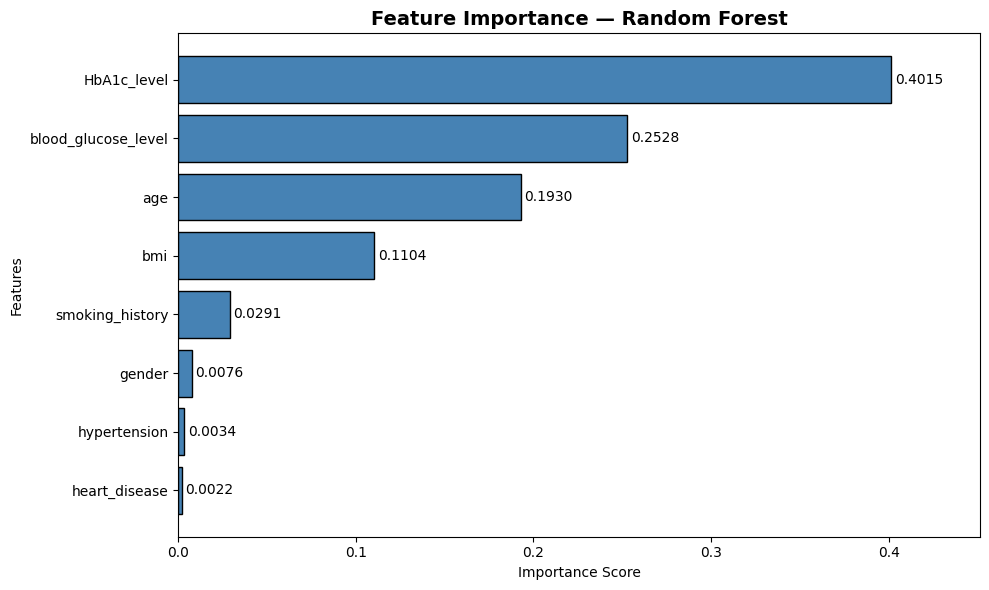

Feature Importance Ranking:
-----------------------------------
1. HbA1c_level               0.4015
2. blood_glucose_level       0.2528
3. age                       0.1930
4. bmi                       0.1104
5. smoking_history           0.0291
6. gender                    0.0076
7. hypertension              0.0034
8. heart_disease             0.0022


In [9]:

# Extract feature importances from Random Forest

feature_names       = df.drop('diabetes', axis=1).columns
importances         = models['Random Forest'].feature_importances_
indices             = np.argsort(importances)[::-1]

sorted_features     = [feature_names[i] for i in indices]
sorted_importances  = [importances[i] for i in indices]


# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(sorted_features[::-1], sorted_importances[::-1],
               color='steelblue', edgecolor='black')

# Add value labels on each bar
for bar, val in zip(bars, sorted_importances[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Features')
ax.set_xlim(0, max(sorted_importances) + 0.05)

plt.tight_layout()
plt.show()

# Print as table too
print("Feature Importance Ranking:")
print("-" * 35)
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances), 1):
    print(f"{i}. {feat:<25} {imp:.4f}")

## Step 8: Conclusion & Project Summary

We have successfully built a complete **Diabetes Prediction System** using machine learning.
Here is a summary of everything we did and what we found.

### What We Did
1. **Loaded and explored** a dataset of 100,000 patient records
2. **Visualized** the data to understand distributions and correlations
3. **Preprocessed** the data — encoded categories, fixed class imbalance with SMOTE, and standardized features
4. **Trained three models** — Logistic Regression, Random Forest, and XGBoost
5. **Evaluated** all models using Accuracy, ROC-AUC, Confusion Matrix, and ROC Curves
6. **Identified** the most important features driving predictions

### Final Model Performance

| Model               | Accuracy | ROC-AUC |
|---------------------|----------|---------|
| Logistic Regression | 88.54%   | 0.9624  |
| XGBoost             | 97.23%   | 0.9968  |
| Random Forest       | 97.52%   | 0.9972  |

### Best Model — Random Forest
Our best performing model is **Random Forest** with:
- **97.52% Accuracy**
- **ROC-AUC of 0.9972** — near perfect separation between diabetic and non-diabetic patients
- Balanced performance on both classes thanks to SMOTE

### Key Medical Insights
From feature importance analysis, the **top predictors of diabetes** are:

1. **HbA1c Level (40%)** — the single most powerful indicator
2. **Blood Glucose Level (25%)** — direct real-time sugar measurement
3. **Age (19%)** — risk increases significantly with age
4. **BMI (11%)** — obesity strongly linked to diabetes

### Final Takeaway
Machine learning can be a powerful tool in **early diabetes detection**. A model like this,
trained on patient data, can assist medical professionals in **flagging high-risk patients**
before symptoms fully develop — enabling earlier intervention and better health outcomes.

## Step 9: Deploying a Prediction App with Gradio

Now we will build an **interactive web app** using **Gradio** that allows anyone to input
a patient's medical details and get an instant diabetes prediction from our trained Random Forest model.

The app will take the following inputs:
- Age, Gender, BMI, HbA1c Level, Blood Glucose Level
- Hypertension, Heart Disease, Smoking History

And it will output:
- **Prediction** — Diabetic or Not Diabetic
- **Confidence Score** — how confident the model is in its prediction

We will then **export everything needed** to deploy this on Hugging Face Spaces.

In [12]:
import gradio as gr
import numpy as np

# -----------------------------------------------
# Encoding maps (same as our LabelEncoder output)
# -----------------------------------------------
gender_map          = {'Female': 0, 'Male': 1, 'Other': 2}
smoking_map         = {
    'No Info':        0,
    'current':        1,
    'ever':           2,
    'former':         3,
    'never':          4,
    'not current':    5
}

# -----------------------------------------------
# Prediction function
# -----------------------------------------------
def predict_diabetes(gender, age, hypertension, heart_disease,
                     smoking_history, bmi, hba1c, blood_glucose):

    gender_enc   = gender_map[gender]
    smoking_enc  = smoking_map[smoking_history]
    hyper_enc    = 1 if hypertension == 'Yes' else 0
    heart_enc    = 1 if heart_disease == 'Yes' else 0

    input_data   = np.array([[gender_enc, age, hyper_enc, heart_enc,
                               smoking_enc, bmi, hba1c, blood_glucose]])

    input_scaled = scaler.transform(input_data)
    prediction   = models['Random Forest'].predict(input_scaled)[0]
    probability  = models['Random Forest'].predict_proba(input_scaled)[0][1]

    if prediction == 1:
        label  = "Diabetic"
        result = f"This patient is likely DIABETIC with {probability * 100:.2f}% confidence."
    else:
        label  = "Not Diabetic"
        result = f"This patient is likely NOT DIABETIC with {(1 - probability) * 100:.2f}% confidence."

    return label, result

# -----------------------------------------------
# Gradio Interface
# -----------------------------------------------
with gr.Blocks(title="Diabetes Prediction App") as app:

    gr.Markdown("# Diabetes Prediction App")
    gr.Markdown("Enter the patient details below to get a prediction from our trained Random Forest model.")

    with gr.Row():
        with gr.Column():
            gender          = gr.Dropdown(choices=['Female', 'Male', 'Other'],
                                          label='Gender')
            age             = gr.Slider(minimum=0, maximum=80, step=1,
                                        label='Age')
            hypertension    = gr.Radio(choices=['Yes', 'No'],
                                       label='Hypertension')
            heart_disease   = gr.Radio(choices=['Yes', 'No'],
                                       label='Heart Disease')

        with gr.Column():
            smoking_history = gr.Dropdown(
                                choices=['No Info', 'current', 'ever',
                                         'former', 'never', 'not current'],
                                label='Smoking History')
            bmi             = gr.Slider(minimum=10.0, maximum=95.0, step=0.1,
                                        label='BMI')
            hba1c           = gr.Slider(minimum=3.5, maximum=9.0, step=0.1,
                                        label='HbA1c Level')
            blood_glucose   = gr.Slider(minimum=80, maximum=300, step=1,
                                        label='Blood Glucose Level')

    predict_btn   = gr.Button("Predict", variant="primary")

    with gr.Row():
        label_out   = gr.Label(label="Prediction")
        result_out  = gr.Textbox(label="Details")

    predict_btn.click(
        fn=predict_diabetes,
        inputs=[gender, age, hypertension, heart_disease,
                smoking_history, bmi, hba1c, blood_glucose],
        outputs=[label_out, result_out]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://518c91f4cd07adf6ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 10: Saving the Model for Deployment

Before deploying to Hugging Face, we need to **save our trained model and scaler** to files.
This way we do not need to retrain the model every time the app runs.

- **joblib** is used to save and load sklearn models efficiently
- We save the **Random Forest model** and the **StandardScaler** separately

In [13]:
import joblib

# Save model and scaler
joblib.dump(models['Random Forest'], 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as: diabetes_model.pkl")
print("Scaler saved as: scaler.pkl")

Model saved as: diabetes_model.pkl
Scaler saved as: scaler.pkl


In [14]:
from google.colab import files

files.download('diabetes_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>